# Binary Sentiment Analysis of Insurance Reviews

This notebook reframes the rating problem as a binary sentiment task, which is easier to learn and easier to interpret than exact star prediction. The workflow mirrors the star-rating notebook so the reader can compare the tasks directly under a consistent methodology.

## Learning Objectives
- Convert the original star-rating labels into a defensible binary sentiment target.
- Compare linear, neural, recurrent, and transformer models on the same validation split.
- Use intermediate outputs to interpret class balance, confusion patterns, and model reliability.
- Highlight representative failure cases rather than reporting metrics alone.
- Produce a clear benchmark presentation appropriate for academic submission.


## Submission Conventions
The notebook explains why each step is necessary before showing the code, then keeps the evaluation protocol stable across models. That structure matters because sentiment performance is only interpretable when label construction, validation, and error analysis are documented carefully.


## Imports

You bring together the libraries for preprocessing, visualization, classical models, neural models, and transformer fine-tuning. Setting the random seed right away keeps the train-validation split and the training runs more reproducible.

In [ ]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from datasets import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


## Loading the data and defining the binary target

In this section, we prepare the dataset for sentiment classification. We convert numerical ratings into binary labels, where ratings of 1 and 2 are considered negative and ratings above 2 are considered positive.

This choice is motivated by class imbalance. Initially, we defined three categories: negative (1–2), neutral (3), and positive (4–5). However, the neutral class was significantly underrepresented compared to the others. In addition, manual inspection showed that many reviews rated 3 tend to express overall positive opinions. For these reasons, we merged neutral with positive to obtain a more balanced and meaningful binary classification.

We then select relevant features and create separate training and test sets based on the data split. Missing values are handled to ensure consistency across text representations.

#### Distribution with 3 classes (negative / neutral / positive)

In [3]:
df = pd.read_csv("dataset_cleaned.csv")

def rating_to_three_classes(note):
    if pd.isna(note):
        return np.nan
    if note <= 2:
        return "negative"
    elif note == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment_3_classes"] = df["note"].apply(rating_to_three_classes)

print(df["sentiment_3_classes"].value_counts())
print(df["sentiment_3_classes"].value_counts(normalize=True).round(3))

sentiment_3_classes
negative    951
positive    790
neutral     259
Name: count, dtype: int64
sentiment_3_classes
negative    0.476
positive    0.395
neutral     0.130
Name: proportion, dtype: float64


We first analyze the distribution of reviews using three classes: negative (ratings 1–2), neutral (rating 3), and positive (ratings 4–5). The results show that the neutral class is significantly underrepresented compared to the negative and positive classes, leading to a strong class imbalance.

#### Sample of reviews with rating = 3

In [4]:
df[df["note"] == 3][["note", "avis"]].sample(10, random_state=42)

,note,avis
499,3.0,Je suis satisfait de la facilité de souscription.\r\nPrix correct même si très élevé pour un jeune conducteur.\r\n....
371,3.0,"Simple et pratique ,j'espère quand meme pouvoir bénéficier d'une baisse de mon assurance dans les meilleurs délais ...."
107,3.0,"JE PAYE CHAQUE ANNEE MA FACTURE D'ASSURANCE ET SUIS EN BONUS. j'entends souvent dire que AXA est mauvais payeur, éga..."
563,3.0,dossier capital décès réglé en moins d'un mois alors qu'il y avait des droits dus aux impôts. J'ai été tenue au cour...
1086,3.0,"Facile et pas cher de s'assurer chez l'olivier. Leur interface web est vraiment bien.\r\nPar contre, après deux ans ..."
821,3.0,JE DONNERAI MON AVIS DEFINITIF PLUS TARD MAIS PAS AU DEBUT DE MON CONTRAT. jE SUIS SATISFAIT DE MES PREMIERS CONTACT...
1649,3.0,Bonjour les tarifs sont tres corrects meme avec les optuins supplementaires choisies.\r\nComparé aux autres assuranc...
1798,3.0,"En cas de sinistre , le service suivi de gestion est totalement inefficace . Aucun suivi , quant à la gestion ? Des ..."
984,3.0,"Je suis satisfait pour la qualité de l'accueil, toutes mes questions ont eu un réponse bien expliqué détaillé. Nivea..."
1694,3.0,"Quad assurer depuis 5 ans, jais de problème jusqu'au jour ou il est volé. La on me dis que les facture de réparation..."


To better understand the nature of neutral reviews, we examine a sample of comments with a rating of 3. This qualitative analysis reveals that many of these reviews express overall positive sentiments despite the intermediate rating.

This observation, combined with the imbalance issue, supports the decision to merge neutral reviews with the positive class for the final binary classification.

#### Train/Test Split and Label Distribution

In [ ]:
def rating_to_binary_sentiment(note):
    if pd.isna(note):
        return np.nan
    if note <= 2:
        return "negative"
    return "positive"


useful_columns = ["note", "type", "avis_en_tfidf_lda", "avis_en_embeddings"]
df_model = df[useful_columns].copy()
df_model["type"] = df_model["type"].astype(str).str.lower().str.strip()
df_model["avis_en_tfidf_lda"] = df_model["avis_en_tfidf_lda"].fillna("").astype(str)
df_model["avis_en_embeddings"] = df_model["avis_en_embeddings"].fillna("").astype(str)
df_model["sentiment"] = df_model["note"].map(rating_to_binary_sentiment)

train_df = df_model[(df_model["type"] == "train") & (df_model["sentiment"].notna())].copy()
test_df = df_model[df_model["type"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Unlabeled test shape:", test_df.shape)
print(train_df["sentiment"].value_counts())
print(train_df["sentiment"].value_counts(normalize=True).round(3))


Train shape: (2000, 5)
Unlabeled test shape: (1000, 5)
sentiment
positive    1049
negative     951
Name: count, dtype: int64
sentiment
positive    0.524
negative    0.476
Name: proportion, dtype: float64


The training set contains 2000 samples, while the test set includes 1000 samples. The class distribution is relatively balanced, with 52.4% positive and 47.6% negative reviews.

This balance is beneficial for model training, as it reduces the risk of bias toward one class and allows for more reliable evaluation.

#### Sentiment Distribution and Review Length Analysis

In this section, we analyze the distribution of binary sentiment labels as well as the average length of reviews for each class.

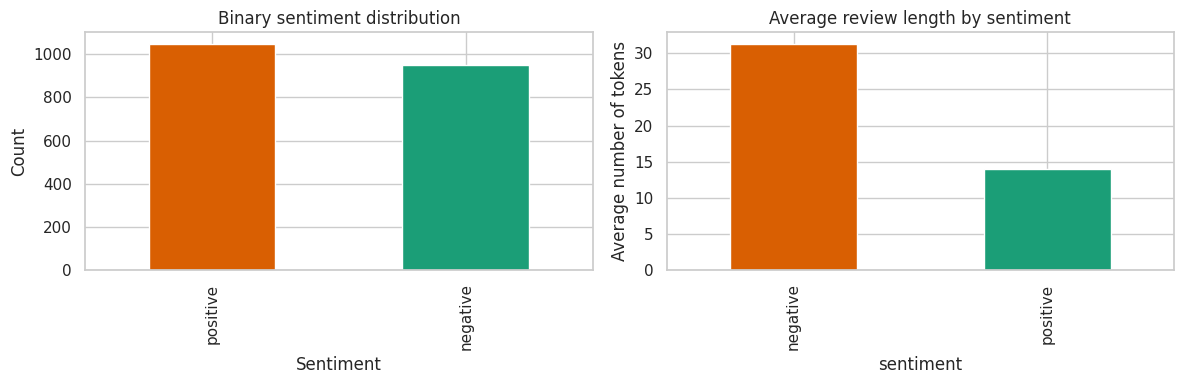

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["#d95f02", "#1b9e77"])
axes[0].set_title("Binary sentiment distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

train_df.groupby("sentiment")["avis_en_tfidf_lda"].apply(lambda s: s.str.split().map(len).mean()).plot(
    kind="bar", ax=axes[1], color=["#d95f02", "#1b9e77"]
)
axes[1].set_title("Average review length by sentiment")
axes[1].set_ylabel("Average number of tokens")

plt.tight_layout()
plt.show()


The sentiment distribution is relatively balanced between positive and negative reviews, which is suitable for training classification models without strong bias toward one class.

We also observe a clear difference in review length: negative reviews tend to be significantly longer on average than positive ones. This suggests that dissatisfied users are more likely to provide detailed feedback, while positive reviews are generally shorter and more concise.

## Target Validation
Before training, we verify that the binary label transformation produced only the two expected classes and that the shared validation split remains stratified. This is a lightweight but essential reproducibility check.


## Preparing the shared split and the evaluation helpers

In this section, we validate the binary sentiment labels and prepare the data for model training and evaluation. We first ensure that only the expected labels (negative and positive) are present and that the class distribution remains consistent.

We then create a stratified validation split to preserve the proportion of each class between the training and validation sets. This is important to ensure a fair and reliable evaluation of model performance.

Finally, we define evaluation functions to compute key classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC, as well as tools to display confusion matrices. These utilities will be used to systematically compare the performance of different models.

In [ ]:
# Validate the binary target and the shared split.
print('Unique sentiment labels:', sorted(train_df['sentiment'].dropna().unique()))
print('Training label distribution:')
print(y_train.value_counts())
print('Validation label distribution:')
print(y_valid.value_counts())
assert set(train_df['sentiment'].dropna().unique()) == {'negative', 'positive'}, 'Unexpected sentiment labels found.'


In [4]:
# Purpose: Preparing the shared split and the evaluation helpers.
# The intermediate output from this cell is kept intentionally for transparency and validation.
SENTIMENT_ORDER = ["negative", "positive"]
label_to_id = {label: idx for idx, label in enumerate(SENTIMENT_ORDER)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

X_tfidf = train_df["avis_en_tfidf_lda"].copy()
X_embed = train_df["avis_en_embeddings"].copy()
y = train_df["sentiment"].copy()

train_idx, valid_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train_tfidf = X_tfidf.loc[train_idx]
X_valid_tfidf = X_tfidf.loc[valid_idx]
X_train_embed = X_embed.loc[train_idx]
X_valid_embed = X_embed.loc[valid_idx]
y_train = y.loc[train_idx]
y_valid = y.loc[valid_idx]

y_train_nn = y_train.map(label_to_id).to_numpy()
y_valid_nn = y_valid.map(label_to_id).to_numpy()

results = []


def evaluate_binary_classification(model_name, y_true, y_pred, y_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label="positive",
        zero_division=0,
    )
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_positive": precision,
        "Recall_positive": recall,
        "F1_positive": f1,
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
    }
    if y_score is not None:
        positive_scores = np.asarray(y_score)
        if positive_scores.ndim == 2:
            positive_scores = positive_scores[:, 1]
        metrics["ROC_AUC"] = roc_auc_score((y_true == "positive").astype(int), positive_scores)

    result = pd.DataFrame([metrics])
    results.append(result)
    cm = confusion_matrix(y_true, y_pred, labels=SENTIMENT_ORDER)
    return result, cm



def show_report(y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=SENTIMENT_ORDER, zero_division=0))



def show_confusion_matrix(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred, labels=SENTIMENT_ORDER),
        display_labels=SENTIMENT_ORDER,
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


print(y_train.value_counts(normalize=True).round(3))
print(y_valid.value_counts(normalize=True).round(3))


sentiment
positive    0.524
negative    0.476
Name: proportion, dtype: float64
sentiment
positive    0.525
negative    0.475
Name: proportion, dtype: float64


## Majority-Class Baseline

Before training more advanced models, we establish a baseline using a simple classifier that always predicts the majority class. This provides a reference point to evaluate whether our models actually learn meaningful patterns beyond class distribution.

In [ ]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_dummy = dummy_clf.predict(np.zeros((len(y_valid), 1)))
results_dummy, cm_dummy = evaluate_binary_classification(
    "Baseline Majority Class", y_valid, y_pred_dummy
)
results_dummy

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Baseline Majority Class,0.525,0.525,1.0,0.688525,0.344262


The baseline achieves an accuracy of around 52.5%, which reflects the proportion of the majority class in the dataset. The recall for the positive class is equal to 1.0, as the model predicts all samples as positive, while the macro F1 score remains low, indicating poor overall performance.

This confirms that relying only on class distribution is insufficient. Any meaningful model should significantly outperform this baseline, especially in terms of balanced metrics such as F1-score and macro F1.

## TF-IDF + Logistic Regression baseline

We train a Logistic Regression model using TF-IDF features as a strong baseline for text classification

In [6]:
# Purpose: Training the TF-IDF Logistic Regression baseline.
# The intermediate output from this cell is kept intentionally for transparency and validation.
logreg_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred_logreg = logreg_tfidf.predict(X_valid_tfidf)
y_score_logreg = logreg_tfidf.predict_proba(X_valid_tfidf)
results_logreg, cm_logreg = evaluate_binary_classification(
    "TF-IDF + Logistic Regression", y_valid, y_pred_logreg, y_score=y_score_logreg
)
results_logreg


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
0,TF-IDF + Logistic Regression,0.8875,0.941176,0.838095,0.88665,0.887494,0.935664


              precision    recall  f1-score   support

    negative       0.84      0.94      0.89       190
    positive       0.94      0.84      0.89       210

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



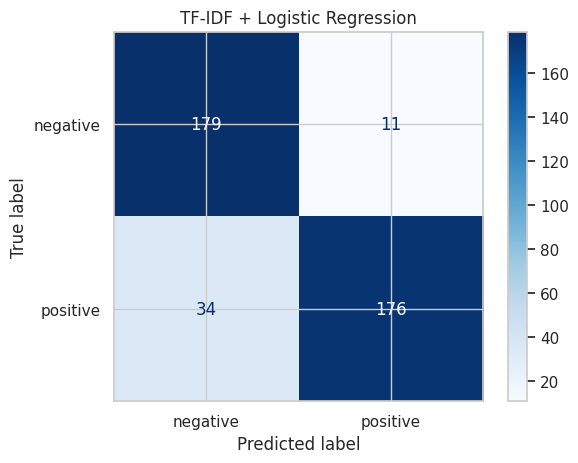

In [ ]:
# Looking at the Logistic Regression errors
show_report(y_valid, y_pred_logreg)
show_confusion_matrix(y_valid, y_pred_logreg, "TF-IDF + Logistic Regression")


The model achieves strong performance with an accuracy of 0.887 and a ROC-AUC of 0.936. Precision is high for both classes (0.94), with a slight imbalance in recall: 0.94 for negative reviews and 0.84 for positive ones.

The confusion matrix confirms these results. Most reviews are correctly classified, with 179 negative and 176 positive predictions correctly identified. However, some errors remain: 34 positive reviews are misclassified as negative, and 11 negative reviews are predicted as positive.

Overall, the model performs well but tends to miss some positive reviews, which may be due to more subtle or ambiguous wording.

## TF-IDF + Linear SVM

We train a Linear SVM model on TF-IDF features as an alternative linear baseline, allowing comparison with Logistic Regression.

In [ ]:
svm_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]
)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_tfidf.predict(X_valid_tfidf)
results_svm, cm_svm = evaluate_binary_classification(
    "TF-IDF + Linear SVM", y_valid, y_pred_svm
)
results_svm

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,TF-IDF + Linear SVM,0.875,0.916667,0.838095,0.875622,0.874997


              precision    recall  f1-score   support

    negative       0.84      0.92      0.87       190
    positive       0.92      0.84      0.88       210

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.87       400
weighted avg       0.88      0.88      0.88       400



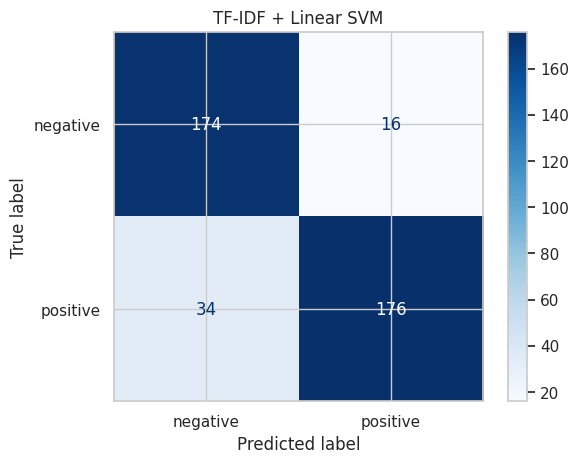

In [ ]:
# Linear SVM confusion matrix.
show_report(y_valid, y_pred_svm)
show_confusion_matrix(y_valid, y_pred_svm, "TF-IDF + Linear SVM")

The Linear SVM achieves an accuracy of 0.875, slightly lower than Logistic Regression. Precision remains high (0.92), with recall at 0.84 for positive reviews and 0.92 for negative ones.

The confusion matrix confirms this behavior. The model correctly classifies 174 negative and 176 positive reviews. However, 34 positive reviews are still misclassified as negative, and 16 negative reviews are predicted as positive.

Overall, the model performs similarly to Logistic Regression but shows a slightly stronger ability to detect negative reviews, while still struggling with some positive cases.

## Preparing text for neural models

The first step consists in transforming raw text into a numerical format that neural networks can process.

We start by tokenizing the reviews. Each word is converted into an integer based on its frequency in the training set. We limit the vocabulary to the 20,000 most frequent words in order to reduce noise and keep only the most relevant information.

Then, we convert each review into a sequence of integers. Since neural networks require inputs of fixed size, we apply padding and truncation to ensure that all sequences have the same length (120 tokens). Short reviews are padded, while longer ones are truncated.

This step is necessary because neural models cannot directly process raw text and require structured numerical input.

In [ ]:
max_words = 20000
max_len = 120
embedding_dim = 128
batch_size = 32
epochs = 10

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_embed.tolist())

X_train_seq = tokenizer.texts_to_sequences(X_train_embed.tolist())
X_valid_seq = tokenizer.texts_to_sequences(X_valid_embed.tolist())

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape, X_valid_pad.shape)


(1600, 120) (400, 120)


## Defining neural architectures

We define two different neural models to compare their ability to capture sentiment.

The first model is a simple dense architecture. It uses an embedding layer to learn word representations, followed by a global average pooling that summarizes the sentence, and a dense layer for classification. This model is fast and serves as a lightweight baseline.

The second model is a BiLSTM. Unlike the dense model, it takes into account the order of words in the sentence. The bidirectional structure allows the model to read the text both forward and backward, which helps capture context and dependencies between words.

Both models use a softmax output layer to perform binary classification.

In [ ]:
# defining the simple dense architecture
def build_dense_model(vocab_size, embedding_dim, max_len):
    model = keras.Sequential(
        [
            layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
            layers.GlobalAveragePooling1D(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# defining BiLSTM model 
def build_bilstm_model(vocab_size, embedding_dim, max_len):
    inputs = keras.Input(shape=(max_len,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    x = layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


## Training visualization

We define a helper function to plot training curves. It allows us to visualize both loss and accuracy over epochs for training and validation sets.

This is useful to detect overfitting. If training performance keeps improving while validation stagnates or decreases, it indicates that the model is memorizing rather than generalizing.

In [ ]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title} - loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title} - accuracy")
    plt.tight_layout()
    plt.show()


## Training + Evaluating the dense neural baseline

We train a dense model with an embedding layer. Early stopping is used to prevent overfitting.

In [ ]:
dense_model = build_dense_model(max_words, embedding_dim, max_len)
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

dense_history = dense_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6831 - loss: 0.6172 - val_accuracy: 0.7700 - val_loss: 0.5626
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7788 - loss: 0.5089 - val_accuracy: 0.8125 - val_loss: 0.5182
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8188 - loss: 0.4336 - val_accuracy: 0.8100 - val_loss: 0.4733
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8587 - loss: 0.3506 - val_accuracy: 0.8000 - val_loss: 0.4358
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9038 - loss: 0.2718 - val_accuracy: 0.7975 - val_loss: 0.4430
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9212 - loss: 0.2267 - val_accuracy: 0.8375 - val_loss: 0.4210
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9306 - loss: 0.1916 - val_accuracy: 0.8500 - val_loss: 0.4122
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9394 - loss: 0.1675 - val_accuracy: 0.8600 - val_loss

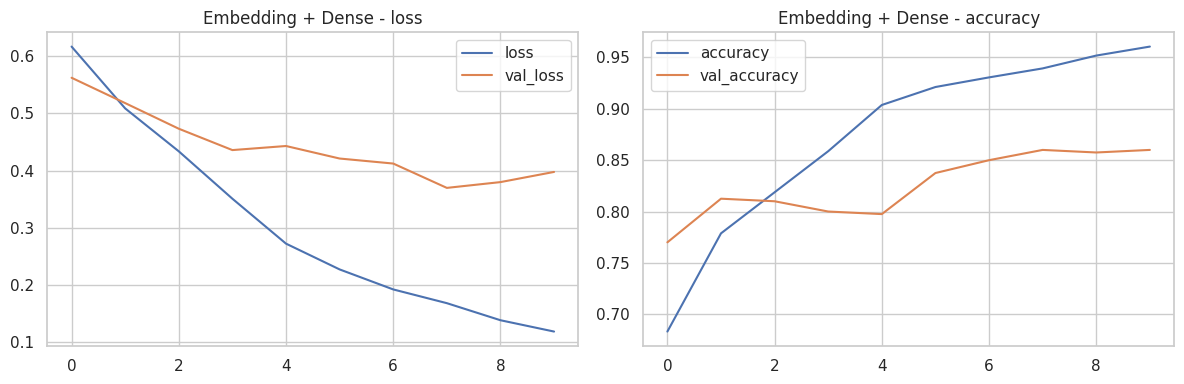

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Embedding Layer + Dense,0.86,0.932584,0.790476,0.85567,0.859874


In [ ]:
# Evaluate the trained dense model on the validation set:
# - plot training curves (loss and accuracy)
# - generate predictions from the model
# - convert predictions back to labels
# - compute evaluation metrics and confusion matrix

plot_history(dense_history, "Embedding + Dense")

y_pred_dense_ids = np.argmax(dense_model.predict(X_valid_pad), axis=1)
y_pred_dense = pd.Series(y_pred_dense_ids, index=y_valid.index).map(id_to_label)
results_dense, cm_dense = evaluate_binary_classification(
    "Embedding Layer + Dense", y_valid, y_pred_dense
)
results_dense

              precision    recall  f1-score   support

    negative       0.80      0.94      0.86       190
    positive       0.93      0.79      0.86       210

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400



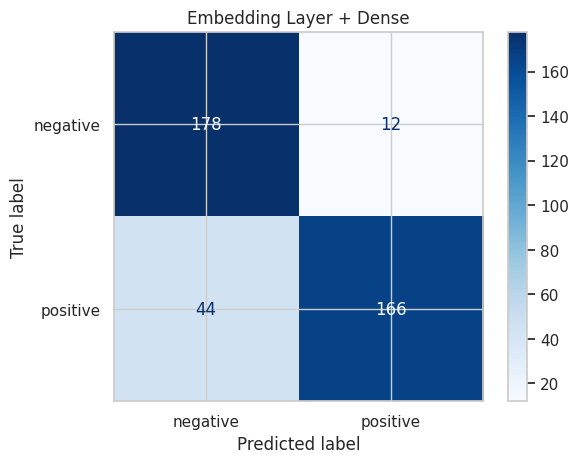

In [ ]:
# Analyze model performance:
# - display detailed classification metrics (precision, recall, F1-score)
# - visualize the confusion matrix to understand prediction errors

show_report(y_valid, y_pred_dense)
show_confusion_matrix(y_valid, y_pred_dense, "Embedding Layer + Dense")


The training curves show a steady decrease in training loss, while validation loss decreases at first and then stabilizes. At the same time, training accuracy keeps increasing, whereas validation accuracy plateaus around 0.85–0.86. This gap indicates slight overfitting: the model continues to improve on the training set but less on unseen data.

Looking at the metrics, the model achieves a high precision for positive reviews (0.93), meaning that positive predictions are reliable. However, recall for positive reviews is lower (0.79), which shows that a significant number of positive reviews are not detected.

On the contrary, the model performs very well on negative reviews, with a recall of 0.94. This imbalance suggests that the model is more confident when identifying negative sentiment.

The confusion matrix confirms this behavior. Most negative reviews are correctly classified (178), with very few errors (12). For positive reviews, the model correctly predicts 166 cases but misclassifies 44 as negative. This indicates a tendency to predict negative when the model is uncertain.

Overall, the model captures general sentiment well but struggles with borderline positive reviews, especially those mixing positive and negative expressions.

## Training + Evaluating the BiLSTM model

We train a BiLSTM model to capture word order and contextual dependencies in the reviews.
Early stopping is used to limit overfitting and keep the best model based on validation loss.

In [ ]:
bilstm_model = build_bilstm_model(max_words, embedding_dim, max_len)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 469ms/step - accuracy: 0.7350 - loss: 0.5297 - val_accuracy: 0.8200 - val_loss: 0.3706
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 451ms/step - accuracy: 0.8925 - loss: 0.2824 - val_accuracy: 0.8475 - val_loss: 0.3453
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 448ms/step - accuracy: 0.9406 - loss: 0.1794 - val_accuracy: 0.8450 - val_loss: 0.4386
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 516ms/step - accuracy: 0.9550 - loss: 0.1386 - val_accuracy: 0.8250 - val_loss: 0.5719


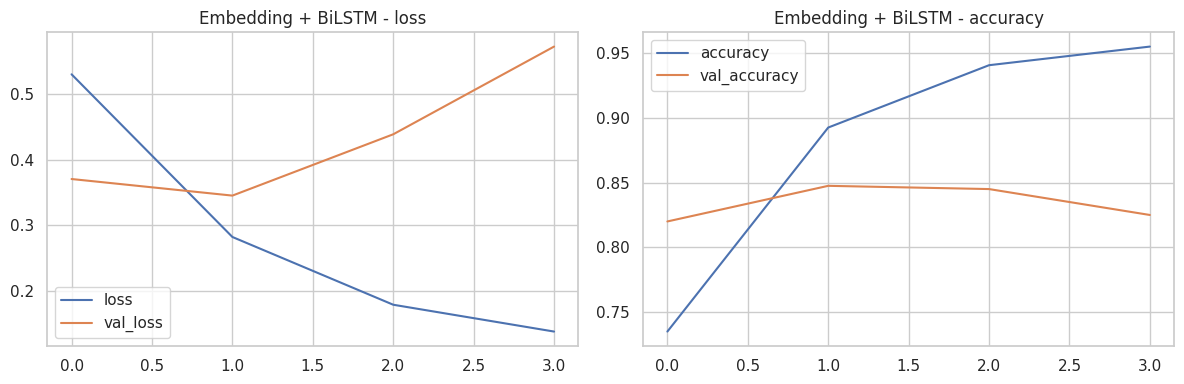

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Embedding Layer + BiLSTM,0.8475,0.866995,0.838095,0.8523,0.847339


In [ ]:
# Evaluate the BiLSTM model on the validation set with the 'plot_history' function 
plot_history(bilstm_history, "Embedding + BiLSTM")

y_pred_bilstm_ids = np.argmax(bilstm_model.predict(X_valid_pad), axis=1)
y_pred_bilstm = pd.Series(y_pred_bilstm_ids, index=y_valid.index).map(id_to_label)
results_bilstm, cm_bilstm = evaluate_binary_classification(
    "Embedding Layer + BiLSTM", y_valid, y_pred_bilstm
)
results_bilstm


In [ ]:
# Display detailed classification metrics with confusion matrix and report
show_report(y_valid, y_pred_bilstm)
show_confusion_matrix(y_valid, y_pred_bilstm, "Embedding Layer + BiLSTM")

The training curves show a rapid decrease in training loss, while validation loss increases after the first epochs. At the same time, training accuracy continues to improve, whereas validation accuracy peaks early and then slightly decreases. This indicates clear overfitting: the model learns the training data well but struggles to generalize.

Looking at the metrics, the model is more balanced than the dense model. Precision and recall are closer for both classes, with 0.87 precision and 0.84 recall for positive reviews, and 0.83 precision and 0.86 recall for negative reviews.

The confusion matrix confirms this balance. The model correctly classifies 163 negative and 176 positive reviews. Errors are more evenly distributed, with 27 negative reviews misclassified as positive and 34 positive reviews misclassified as negative.

Compared to the dense model, the BiLSTM captures more context and reduces bias toward one class. However, this comes at the cost of stronger overfitting and slightly lower overall performance.

## DistilBERT: data preparation, training and evaluation

### Preparing the DistilBERT datasets

We prepare the data in a format compatible with Hugging Face transformers.
The text and labels are converted into datasets, then tokenized using DistilBERT’s tokenizer. Padding and truncation are applied to ensure consistent input length.

In [ ]:
bert_model_name = "distilbert-base-uncased"

bert_train_df = pd.DataFrame(
    {
        "text": X_train_embed.reset_index(drop=True),
        "label": pd.Series(y_train_nn),
    }
)
bert_valid_df = pd.DataFrame(
    {
        "text": X_valid_embed.reset_index(drop=True),
        "label": pd.Series(y_valid_nn),
    }
)

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_valid_dataset = Dataset.from_pandas(bert_valid_df)

tokenizer_bert = AutoTokenizer.from_pretrained(bert_model_name)

# Tokenization function:
# - converts text into input_ids (token indices)
# - applies padding to fixed length
# - truncates long sequences to max_length
def tokenize_function(batch):
    return tokenizer_bert(batch["text"], padding="max_length", truncation=True, max_length=128)


bert_train_dataset = bert_train_dataset.map(tokenize_function, batched=True)
bert_valid_dataset = bert_valid_dataset.map(tokenize_function, batched=True)

# Format datasets for PyTorch:
# keep only useful columns for the model (input_ids, attention_mask, label)
bert_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
bert_valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

### Configuring DistilBERT and its metrics

We initialize a pre-trained DistilBERT model for sequence classification.

Custom evaluation metrics are defined, including accuracy, macro F1, and positive class F1, to allow comparison with previous models.

Training parameters are set with a lightweight configuration for fast experimentation.

In [21]:
# Purpose: Configuring DistilBERT and its metrics.
# The intermediate output from this cell is kept intentionally for transparency and validation.
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2,
    id2label=id_to_label,
    label2id=label_to_id,
)


def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "positive_f1": f1_score(labels, preds, average="binary", pos_label=1),
    }


training_args = TrainingArguments(
    output_dir="./binary_sentiment_distilbert_runs",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_valid_dataset,
    compute_metrics=compute_bert_metrics,
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Fine-tuning DistilBERT

We fine-tune the model on the training data and evaluate it on the validation set.

This step adapts the pre-trained language model to the sentiment classification task.

In [22]:
trainer.train()
trainer.evaluate()

Step,Training Loss
50,0.451501
100,0.290854
150,0.205824
200,0.240968


{'eval_loss': 0.26729702949523926,
 'eval_accuracy': 0.91,
 'eval_macro_f1': 0.9099977499437486,
 'eval_positive_f1': 0.9104477611940298,
 'eval_runtime': 1.5546,
 'eval_samples_per_second': 257.294,
 'eval_steps_per_second': 16.081,
 'epoch': 2.0}

### Scoring DistilBERT on the validation set

We generate predictions and convert them into labels and probabilities.

This allows us to compute classification metrics and compare DistilBERT with previous models using the same evaluation framework.

In [23]:
# Purpose: Scoring DistilBERT on the validation set.
# The intermediate output from this cell is kept intentionally for transparency and validation.
bert_predictions = trainer.predict(bert_valid_dataset)
y_pred_bert_ids = np.argmax(bert_predictions.predictions, axis=1)
y_pred_bert = pd.Series(y_pred_bert_ids, index=y_valid.index).map(id_to_label)
y_score_bert = tf.nn.softmax(bert_predictions.predictions, axis=1).numpy()
results_bert, cm_bert = evaluate_binary_classification(
    "DistilBERT", y_valid, y_pred_bert, y_score=y_score_bert
)
results_bert


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
0,DistilBERT,0.91,0.953125,0.871429,0.910448,0.909998,0.947368


### Results analysis

              precision    recall  f1-score   support

    negative       0.87      0.95      0.91       190
    positive       0.95      0.87      0.91       210

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



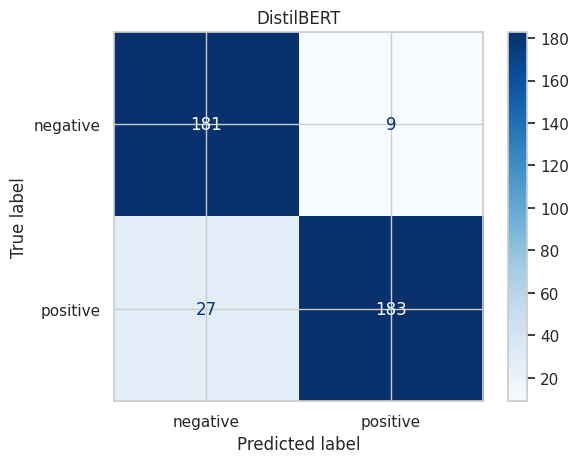

In [24]:
# Purpose: Failure Cases from DistilBERT.
# The intermediate output from this cell is kept intentionally for transparency and validation.
show_report(y_valid, y_pred_bert)
show_confusion_matrix(y_valid, y_pred_bert, "DistilBERT")


The model achieves strong performance across all metrics. Precision is high for both classes (0.87 for negative and 0.95 for positive), indicating reliable predictions.

Recall is also well balanced, with 0.95 for negative reviews and 0.87 for positive reviews. This shows that the model effectively captures both classes, with slightly better detection of negative reviews.

The confusion matrix confirms these results. The model correctly classifies 181 negative and 183 positive reviews. Errors are limited, with 9 negative reviews misclassified as positive and 27 positive reviews misclassified as negative.

Compared to previous models, DistilBERT improves overall performance and reduces bias toward one class. It better captures context and handles more complex or ambiguous reviews.

## Final evaluation and model selection

### Collecting the final benchmark

All model results are aggregated into a single table to enable consistent comparison.
Sorting by key metrics such as Macro F1, F1 score, and Accuracy helps identify the strongest model overall.

This step provides a global view of performance and avoids relying on isolated results.

In [ ]:
all_results = pd.concat(results, ignore_index=True).sort_values(
    ["Macro_F1", "F1_positive", "Accuracy"],
    ascending=False,
)
all_results

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
5,DistilBERT,0.9100,0.953125,0.871429,0.910448,0.909998,0.947368
1,TF-IDF + Logistic Regression,0.8875,0.941176,0.838095,0.886650,0.887494,0.935664
2,TF-IDF + Linear SVM,0.8750,0.916667,0.838095,0.875622,0.874997,NaN
3,Embedding Layer + Dense,0.8600,0.932584,0.790476,0.855670,0.859874,NaN
4,Embedding Layer + BiLSTM,0.8475,0.866995,0.838095,0.852300,0.847339,NaN
0,Baseline Majority Class,0.5250,0.525000,1.000000,0.688525,0.344262,NaN


### Visualizing the model ranking

The benchmark table is transformed into a visual ranking to improve readability and interpretation. It is a simple but effective way to show whether the best model wins by a clear margin or only by a tiny edge.

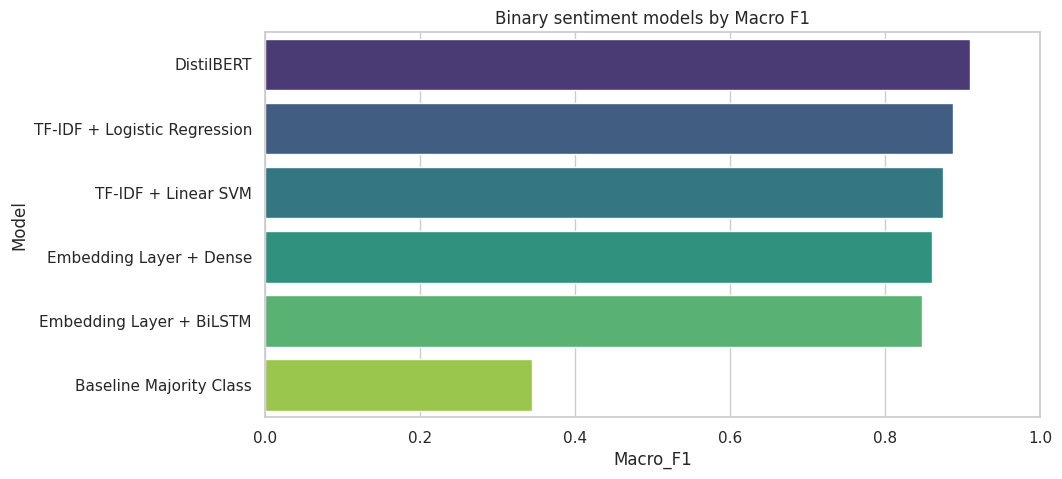

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results, x="Macro_F1", y="Model", palette="viridis")
plt.title("Binary sentiment models by Macro F1")
plt.xlim(0, 1)
plt.show()

### Global conclusion

The final benchmark table and the ranking visualization highlight clear differences between the models.

DistilBERT achieves the best overall performance, with an accuracy of 0.910 and a Macro F1 score of 0.910.
It consistently ranks first in the bar chart, confirming its dominance across all evaluation metrics.

TF-IDF + Logistic Regression appears as a strong baseline, with an accuracy of 0.8875 and a Macro F1 of 0.8875.
The ranking visualization shows that it remains close to DistilBERT, with only a small performance gap. This indicates that simple linear models with well-engineered features already capture most of the sentiment signal.

TF-IDF + Linear SVM follows closely, with slightly lower performance (Macro F1 around 0.875), confirming that linear models are well adapted to this task.

Neural models based on embeddings show lower performance:

- Dense model: Macro F1 ≈ 0.86
- BiLSTM: Macro F1 ≈ 0.847

Despite their higher complexity, they rank below classical approaches in the chart. This suggests that capturing word order and sequence dependencies does not provide a strong advantage for this dataset.

The baseline majority class model performs significantly worse (Macro F1 ≈ 0.34), which confirms that the task is meaningful and requires proper modeling.

The visualization reinforces these observations:

- DistilBERT clearly stands at the top
- Classical models form a strong middle group
- Neural embedding models lag slightly behind
- The baseline is far below all other approaches

Overall, the results show that performance gains plateau quickly after classical methods.
DistilBERT still provides the best balance between precision and recall, as well as the highest robustness across metrics.

DistilBERT is therefore selected as the final model for inference.

## Preparing for final inference

The test dataset is prepared for the final prediction phase.

At this stage:

- no labels are available
- predictions must be generated using the selected model

Multiple text representations (embeddings and TF-IDF) are kept to preserve flexibility in the final model choice.

In [ ]:
final_inference_df = test_df[["avis_en_embeddings", "avis_en_tfidf_lda"]].copy()
final_inference_df.head()

,avis_en_embeddings,avis_en_tfidf_lda
2000,customer of + years with no claims except that of a burglary in no. It's been more than months since my file has bee...,years burglary it's months dragging time didn't expect kind treatment
2001,insured then canceled my insurance for IT reasons the house suddenly became too big to be insured even though the su...,insured canceled reasons house suddenly big insured surface area plans communicated varied deal flat passes it's it'...
2002,I have been insured with Macif for almost a year for my home insurance and am determined to leave very quickly follo...,insured macif year home determined leave quickly following disaster happened yesterday trying contact morning waitin...
2003,insured with Macif for years my insurance was canceled due to excessive losses some water damage over the last three...,insured macif years canceled excessive losses water damage years neighbor reimbursement macif proportion compensatio...
2004,insurer really to be avoided refuses to compensate us following a burglary after a long wait very disappointed on yo...,really avoided refuses compensate following burglary long wait disappointed way handling files
